In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from tqdm.auto import tqdm

sys.path.append(os.path.abspath(".."))

from src.read_code15 import load_metadata as load_code
from src.read_code15 import get_ecg_by_exam_id as get_code_ecg


#Plotting settings
sns.set_theme(style="whitegrid", font_scale=1.1)

FIGSIZE_MAIN = (8, 5)
FIGSIZE_ECG_12 = (12, 14)
FIGSIZE_ECG_SINGLE = (12, 3)

COLOR_MALE = "#4C72B0"       
COLOR_FEMALE = "#C44E52"     
COLOR_NEGATIVE = "#4C72B0"   
COLOR_POSITIVE = "#C44E52"   
COLOR_ECG = "#2F2F2F"      

GENDER_PALETTE = {
    "Male": COLOR_MALE,
    "Female": COLOR_FEMALE
}

CHAGAS_PALETTE = {
    "Negative": COLOR_NEGATIVE,
    "Positive": COLOR_POSITIVE
}

### EDA of metadata

In [ ]:
code_df = load_code()
code_df = code_df.drop(columns=["death", "timey", "nn_predicted_age", "normal_ecg", "dataset"])

print("Shape:", code_df.shape)
print("\nColumns:")
print(code_df.columns.tolist())

print("\nChagas counts:")
print(code_df["chagas"].value_counts())

print("\nChagas proportions (%):")
print(code_df["chagas"].value_counts(normalize=True) * 100)

code_df.head()

Shape: (343424, 12)

Columns:
['exam_id', 'age', 'is_male', '1dAVb', 'RBBB', 'LBBB', 'SB', 'ST', 'AF', 'patient_id', 'trace_file', 'chagas']

Chagas counts:
chagas
0    336863
1      6561
Name: count, dtype: int64

Chagas proportions (%):
chagas
0    98.089534
1     1.910466
Name: proportion, dtype: float64


,exam_id,age,is_male,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,trace_file,chagas
0,1169160,38,True,False,False,False,False,False,False,523632,exams_part13.hdf5,0
1,2873686,73,True,False,False,False,False,False,False,1724173,exams_part13.hdf5,0
2,168405,67,True,False,False,False,False,False,True,51421,exams_part13.hdf5,0
3,271011,41,True,False,False,False,False,False,False,1737282,exams_part13.hdf5,0
4,384368,73,True,False,False,False,False,False,False,331652,exams_part13.hdf5,0


In [ ]:
code_df["Chagas"] = code_df["chagas"].map({
    0: "Negative",
    1: "Positive"
})

code_df["Gender"] = code_df["is_male"].map({
    False: "Female",
    True: "Male"
})

C:\Users\benas\AppData\Local\Temp\ipykernel_22268\2854873434.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


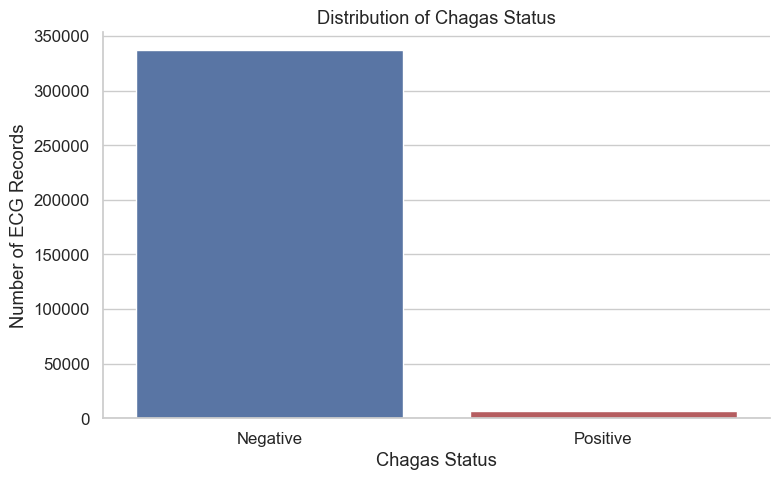

In [ ]:
plt.figure(figsize=FIGSIZE_MAIN)

ax = sns.countplot(
    data=code_df,
    x="Chagas",
    order=["Negative", "Positive"],
    palette=CHAGAS_PALETTE
)

plt.title("Distribution of Chagas Status")
plt.xlabel("Chagas Status")
plt.ylabel("Number of ECG Records")
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\benas\AppData\Local\Temp\ipykernel_22268\2415840364.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


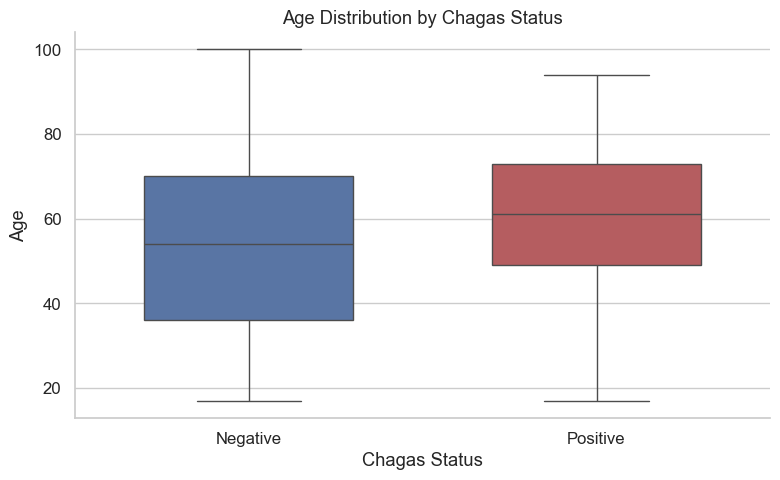

In [ ]:
plt.figure(figsize=FIGSIZE_MAIN)

ax = sns.boxplot(
    data=code_df,
    x="Chagas",
    y="age",
    order=["Negative", "Positive"],
    palette=CHAGAS_PALETTE,
    width=0.6
)

plt.title("Age Distribution by Chagas Status")
plt.xlabel("Chagas Status")
plt.ylabel("Age")

sns.despine()
plt.tight_layout()
plt.show()

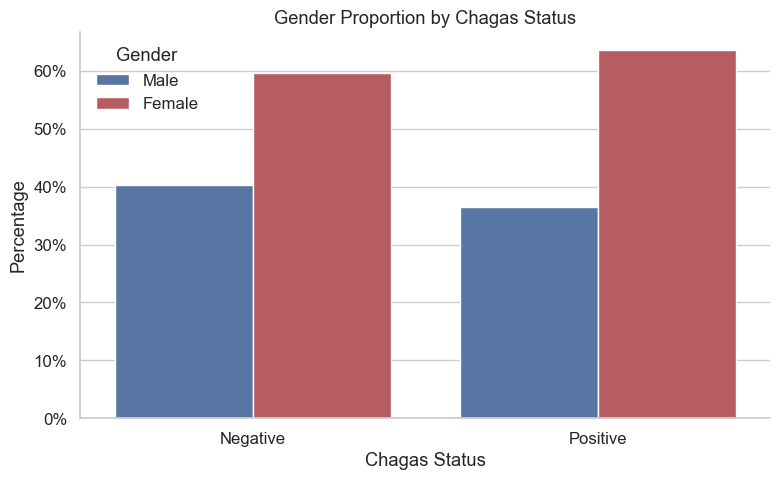

In [ ]:
gender_chagas = (
    code_df
    .groupby("Chagas")["Gender"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

plt.figure(figsize=FIGSIZE_MAIN)

ax = sns.barplot(
    data=gender_chagas,
    x="Chagas",
    y="proportion",
    hue="Gender",
    order=["Negative", "Positive"],
    hue_order=["Male", "Female"],
    palette=GENDER_PALETTE
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title("Gender Proportion by Chagas Status")
plt.xlabel("Chagas Status")
plt.ylabel("Percentage")
plt.legend(title="Gender", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
abnormalities = ["RBBB", "1dAVb", "AF", "LBBB", "SB", "ST"]

table = []

for col in abnormalities:
    if col in code_df.columns:
        vals = code_df.groupby("Chagas")[col].mean() * 100

        table.append({
            "Abnormality": col,
            "Non-Chagas (%)": vals.get("Negative", 0),
            "Chagas (%)": vals.get("Positive", 0)
        })

df_table = pd.DataFrame(table).round(2)

print(df_table)

  Abnormality  Non-Chagas (%)  Chagas (%)
0        RBBB            2.43       19.97
1       1dAVb            1.60        4.07
2          AF            1.94        6.16
3        LBBB            1.71        3.40
4          SB            1.59        3.17
5          ST            2.22        1.57


### EDA for ECG's

In [ ]:
lead_names = ["I", "II", "III", "aVR", "aVL", "aVF", 
              "V1", "V2", "V3", "V4", "V5", "V6"]

#Function to plot 12-lead ECG
def plot_12lead_ecg(ecg, row, title_status, color=COLOR_ECG):
    fig, axes = plt.subplots(
        12, 
        1, 
        figsize=FIGSIZE_ECG_12, 
        sharex=True
    )

    for i in range(12):
        axes[i].plot(ecg[:, i], linewidth=0.8, color=color)
        axes[i].set_ylabel(
            lead_names[i],
            rotation=0,
            labelpad=20,
            fontsize=10
        )
        axes[i].grid(True, alpha=0.25)

    axes[-1].set_xlabel("Sample")

    fig.suptitle(
        f"12-lead ECG (Exam_id={row['exam_id']}, Chagas={title_status})",
        y=0.995,
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

Random Chagas negative exam_id: 3004756
Random Chagas positive exam_id: 2680498
ECG shape for Chagas negative: (4096, 12)
ECG shape for Chagas positive: (4096, 12)


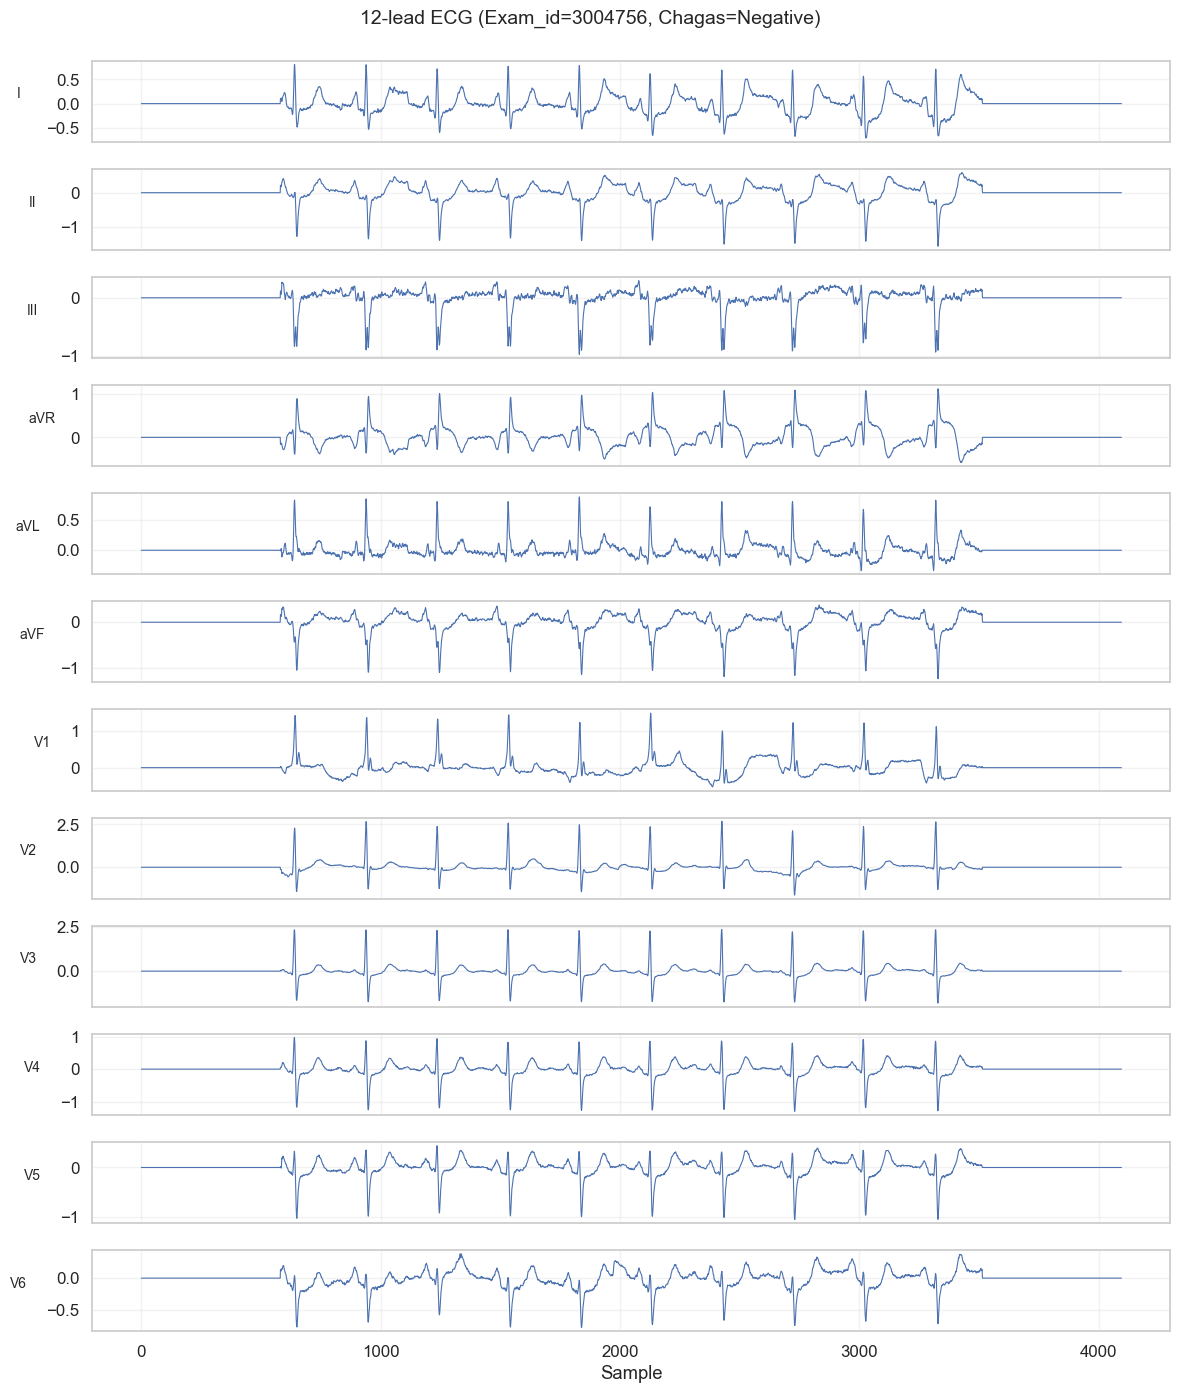

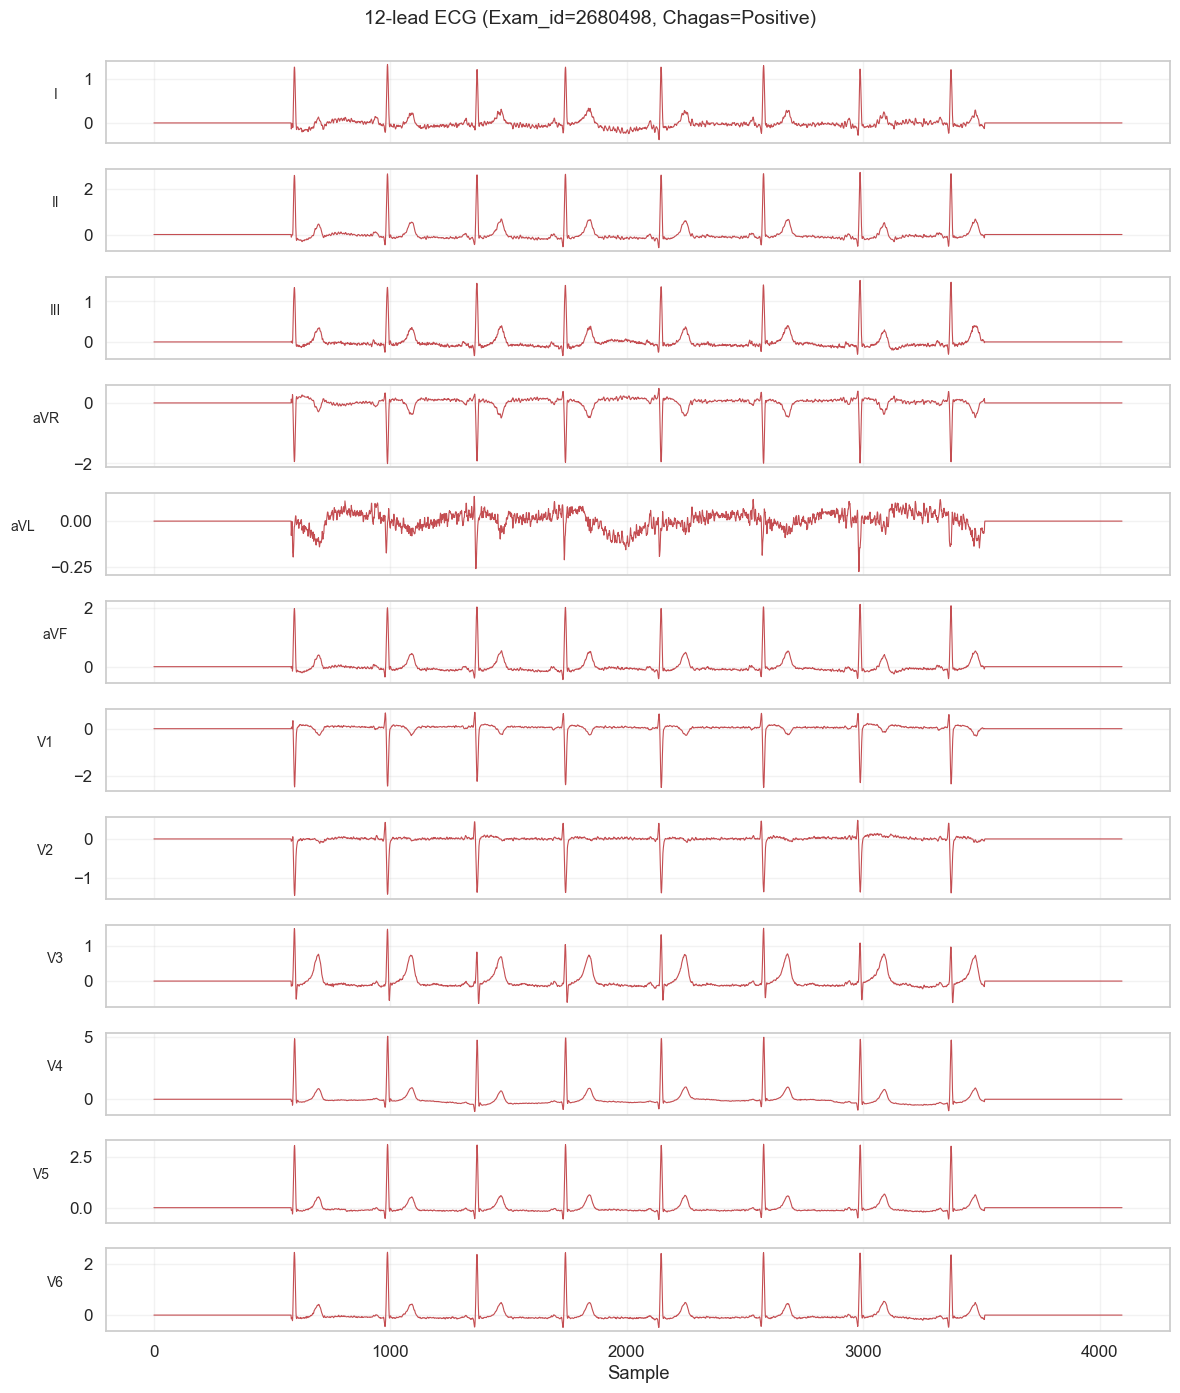

In [ ]:
exam_id_0 = code_df.loc[code_df["chagas"] == 0, "exam_id"].sample(1, random_state=1).iloc[0]
exam_id_1 = code_df.loc[code_df["chagas"] == 1, "exam_id"].sample(1, random_state=1).iloc[0]

print("Random Chagas negative exam_id:", exam_id_0)
print("Random Chagas positive exam_id:", exam_id_1)

ecg_0, row_0 = get_code_ecg(code_df, exam_id_0)
ecg_1, row_1 = get_code_ecg(code_df, exam_id_1)

print("ECG shape for Chagas negative:", ecg_0.shape)
print("ECG shape for Chagas positive:", ecg_1.shape)

plot_12lead_ecg(
    ecg=ecg_0,
    row=row_0,
    title_status="Negative",
    color=COLOR_NEGATIVE
)

plot_12lead_ecg(
    ecg=ecg_1,
    row=row_1,
    title_status="Positive",
    color=COLOR_POSITIVE
)

In [ ]:
# Function for plotting single lead ECG
def plot_single_lead_ecg(ecg, row, lead_idx, title_status, color=COLOR_ECG):
    fig, ax = plt.subplots(figsize=FIGSIZE_ECG_SINGLE)

    ax.plot(
        ecg[:, lead_idx],
        linewidth=0.8,
        color=color
    )

    ax.set_ylabel(lead_names[lead_idx])
    ax.set_xlabel("Sample")
    ax.grid(True, alpha=0.25)

    fig.suptitle(
        f"ECG Lead {lead_names[lead_idx]} "
        f"(Exam_id={row['exam_id']}, Chagas={title_status})",
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

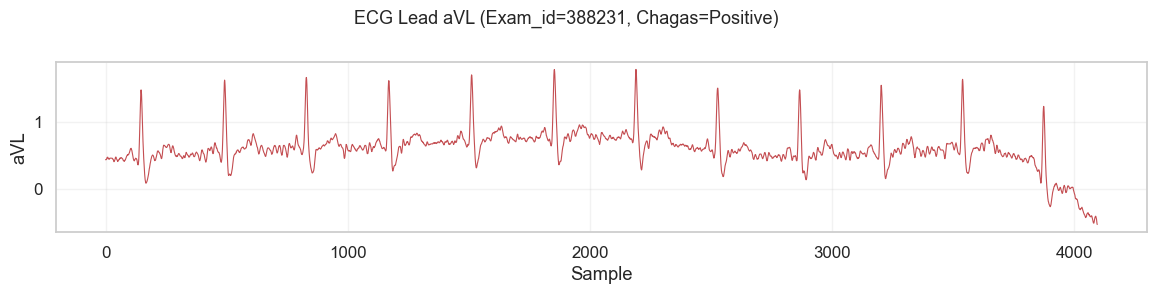

In [ ]:
# Plotting Lead with baseline drift
exam_id_2 = 388231

ecg_2, row_2 = get_code_ecg(code_df, exam_id_2)

lead_idx = 4

status = "Positive" if row_2["chagas"] == 1 else "Negative"
color = COLOR_POSITIVE if status == "Positive" else COLOR_NEGATIVE

plot_single_lead_ecg(
    ecg=ecg_2,
    row=row_2,
    lead_idx=lead_idx,
    title_status=status,
    color=color
)

In [ ]:
def is_flat_ecg(ecg, std_threshold=0.01):
    return ecg.std() < std_threshold

flat_exam_id = None

for exam_id in code_df["exam_id"]:
    ecg, _ = get_code_ecg(code_df, exam_id)

    if is_flat_ecg(ecg):
        flat_exam_id = exam_id
        break

print("Flat ECG exam_id:", flat_exam_id)

Flat ECG exam_id: 1460876


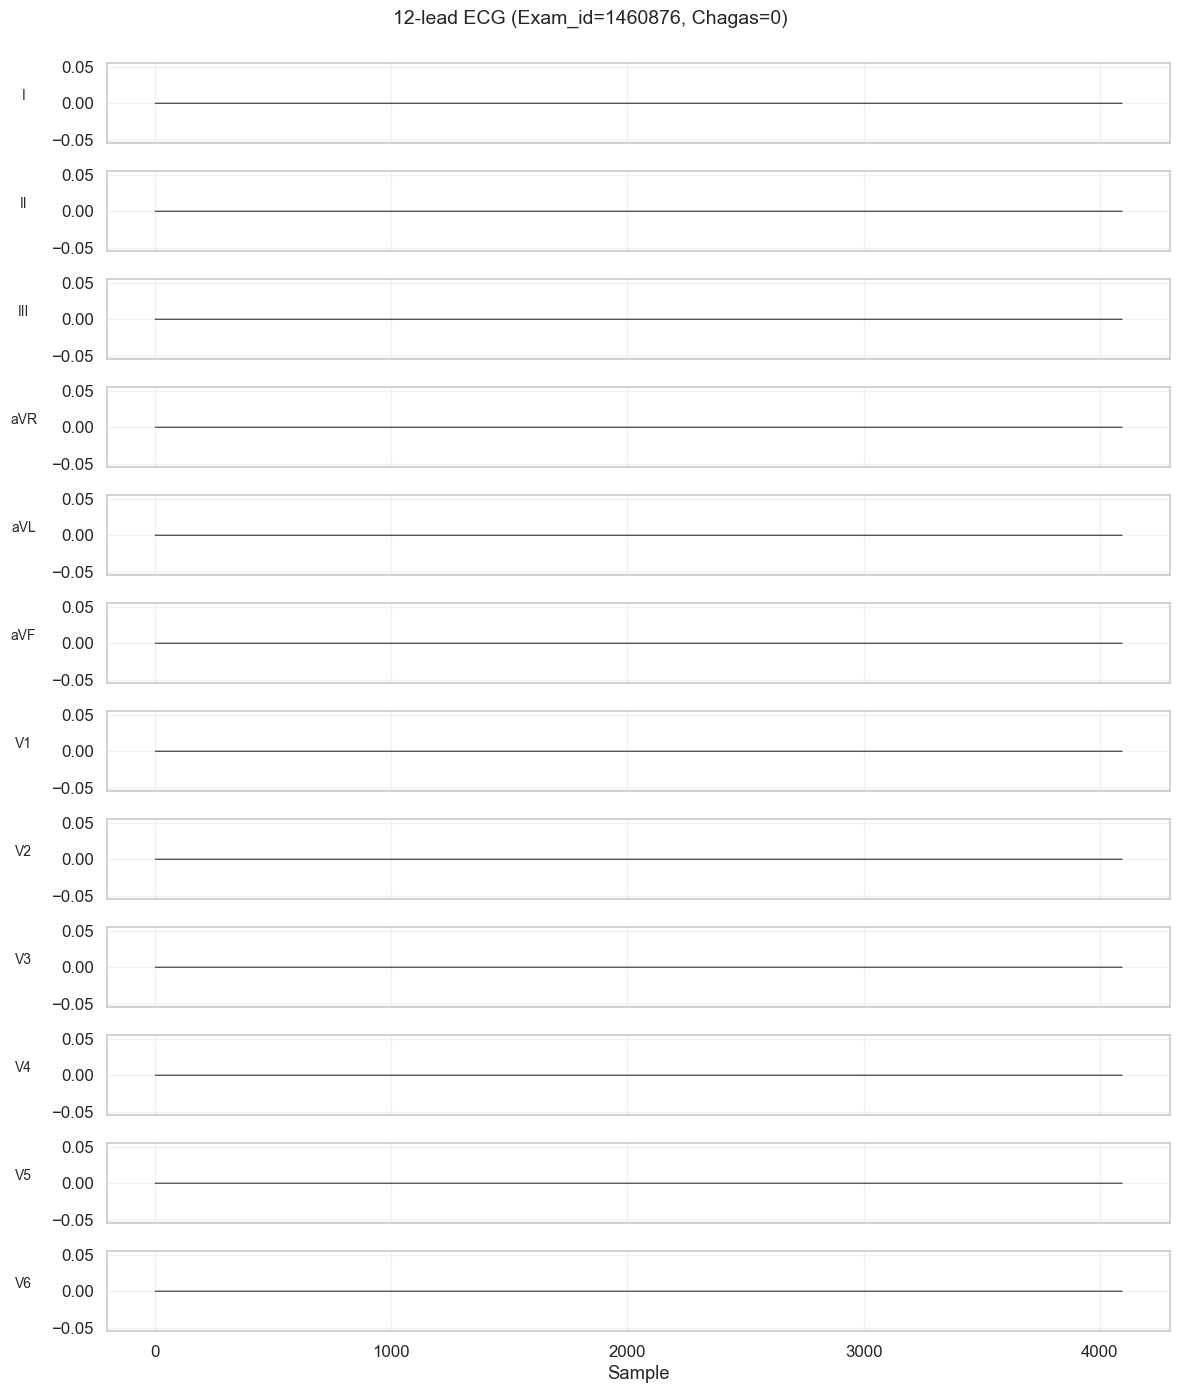

In [ ]:
if flat_exam_id is not None:
    ecg_flat, row_flat = get_code_ecg(code_df, flat_exam_id)

    plot_12lead_ecg(
        ecg=ecg_flat,
        row=row_flat,
        title_status=f"{row_flat['chagas']}",
        color=COLOR_ECG
    )
else:
    print("No flat ECG found.")

In [ ]:
signal_stats = []
#Creating a DataFrame to store signal statistics
for _, row in tqdm(code_df.iterrows(), total=len(code_df), desc="Processing ECG recordings"):
    exam_id = int(row["exam_id"])

    try:
        ecg = get_code_ecg(code_df, exam_id)[0]
        ecg = np.asarray(ecg, dtype=float)

        signal_stats.append({
            "exam_id": exam_id,
            "min_signal": np.nanmin(ecg),
            "max_signal": np.nanmax(ecg),
            "mean_signal": np.nanmean(ecg),
            "std_signal": np.nanstd(ecg),
            "error": None
        })

    except Exception as e:
        signal_stats.append({
            "exam_id": exam_id,
            "min_signal": np.nan,
            "max_signal": np.nan,
            "mean_signal": np.nan,
            "std_signal": np.nan,
            "error": str(e)
        })

signal_stats_df = pd.DataFrame(signal_stats)

signal_stats_df.head()

Processing ECG recordings: 100%|██████████| 343424/343424 [45:30<00:00, 125.75it/s] 


Successful: 343424
Failed: 0


,exam_id,min_signal,max_signal,mean_signal,std_signal,error
0,1169160,-3.312352,2.713986,-0.000515,0.271570,None
1,2873686,-3.136761,3.332198,0.000130,0.267659,None
2,168405,-1.771605,5.560178,-0.000607,0.332612,None
3,271011,-4.946702,7.644940,0.046695,2.010973,None
4,384368,-6.673437,9.199242,1.429885,3.629290,None


In [ ]:
#Table summarizing signal statistics
signal_stats_df.describe()

,exam_id,min_signal,max_signal,mean_signal,std_signal
count,3.434240e+05,343424.000000,343424.000000,343424.000000,343424.000000
mean,1.498991e+06,-4.680937,4.981817,-0.066588,0.917209
std,1.107844e+06,4.645210,4.750320,0.445390,1.017197
min,1.300000e+01,-284.442230,0.000000,-9.744732,0.000000
25%,6.308185e+05,-5.091129,2.657941,-0.088988,0.272207
50%,1.256320e+06,-3.341970,3.623454,0.000196,0.447845
75%,1.971433e+06,-2.375401,5.331116,0.002638,1.200098
max,4.416614e+06,0.000000,285.287323,6.521534,18.092921


In [ ]:
# Finding recordings with extreme amplitude values using IQR method
def iqr_bounds(x):
    x = x.dropna()
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return q1, q3, iqr, lower, upper

min_q1, min_q3, min_iqr, min_lower, min_upper = iqr_bounds(signal_stats_df["min_signal"])
max_q1, max_q3, max_iqr, max_lower, max_upper = iqr_bounds(signal_stats_df["max_signal"])

signal_stats_df["extreme_amplitude"] = (
    (signal_stats_df["min_signal"] < min_lower) |
    (signal_stats_df["max_signal"] > max_upper)
)

n_valid = signal_stats_df[["min_signal", "max_signal"]].dropna().shape[0]
n_extreme = signal_stats_df["extreme_amplitude"].sum()
pct_extreme = 100 * n_extreme / n_valid

print("Minimum signal value:")
print(f"Q1 = {min_q1:.3f}")
print(f"Q3 = {min_q3:.3f}")
print(f"IQR = {min_iqr:.3f}")
print(f"Lower bound = {min_lower:.3f}")
print(f"Upper bound = {min_upper:.3f}")

print("\nMaximum signal value:")
print(f"Q1 = {max_q1:.3f}")
print(f"Q3 = {max_q3:.3f}")
print(f"IQR = {max_iqr:.3f}")
print(f"Lower bound = {max_lower:.3f}")
print(f"Upper bound = {max_upper:.3f}")

print("\nExtreme amplitude recordings:")
print(f"n = {n_extreme}")
print(f"percent = {pct_extreme:.2f}%")

Minimum signal value:
Q1 = -5.091
Q3 = -2.375
IQR = 2.716
Lower bound = -9.165
Upper bound = 1.698

Maximum signal value:
Q1 = 2.658
Q3 = 5.331
IQR = 2.673
Lower bound = -1.352
Upper bound = 9.341

Extreme amplitude recordings:
n = 45060
percent = 13.12%
